In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [ ]:
df = pd.read_csv("/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv")

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
print(df.shape)

(301, 9)


In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0])

Missing values per column:


,0


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189,6.372093
std,2.891554,5.082812,8.644115,38886.883882,0.247915,2.891554
min,2003.000000,0.100000,0.320000,500.000000,0.000000,2.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000,4.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000,6.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000,8.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000,17.000000


In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


## Problem Statement

**Predicting the Selling Price of Used Cars based on various features to assist buyers and sellers in the car market.**

This task involves analyzing the provided car dataset to build a predictive model that can estimate the selling price of a used car given its attributes. Such a model can be valuable for:
*   **Buyers:** To get a fair estimate of a car's value.
*   **Sellers:** To price their cars competitively.
*   **Market Analysts:** To understand factors influencing car prices.

## Solution: Car Price Prediction Model

### 1. Feature Engineering and Preprocessing

In [ ]:
# Calculate car age from the 'Year' column
df['Car_Age'] = 2020 - df['Year'] # Assuming the data collection year is around 2020 or recent for calculation

# Drop original 'Year' column as 'Car_Age' captures this information
# Also drop 'Car_Name' as it's not directly useful for a numerical model
df_processed = df.drop(columns=['Year', 'Car_Name'])

# Display the first few rows with the new 'Car_Age' column
print("DataFrame after adding Car_Age and dropping Year, Car_Name:")
display(df_processed.head())

DataFrame after adding Car_Age and dropping Year, Car_Name:


,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


In [ ]:
# One-hot encode categorical features
# Identify categorical columns
categorical_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print("DataFrame after One-Hot Encoding:")
display(df_encoded.head())

DataFrame after One-Hot Encoding:


,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,False,True,False,True
1,4.75,9.54,43000,0,7,True,False,False,True
2,7.25,9.85,6900,0,3,False,True,False,True
3,2.85,4.15,5200,0,9,False,True,False,True
4,4.60,6.87,42450,0,6,True,False,False,True


### 2. Model Training and Evaluation

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Define features (X) and target (y)
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (240, 8)
Testing features shape: (61, 8)
Training target shape: (240,)
Testing target shape: (61,)


In [ ]:
# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared score for the Car Price Prediction Model: {r2:.2f}")

R-squared score for the Car Price Prediction Model: 0.96


### User-Friendly Application: Helping a Buyer Find the 'Best' Second-Hand Car

For someone looking to buy a second-hand car, the 'best' often means a good car at a fair price. Our model can help by predicting a fair selling price based on a car's features. This allows buyers to compare listed prices against predicted values to identify potentially undervalued cars or avoid overpaying.

Let's simulate how a buyer might use this for a specific car.

In [ ]:
import pandas as pd

# Define features for a hypothetical used car a buyer is interested in
# These features must match the columns used for training the model (X)
hypothetical_car = {
    'Present_Price': [8.0],  # Present price in Lakhs
    'Kms_Driven': [50000],  # Kilometers Driven
    'Owner': [0],          # Number of previous owners (0 for first owner)
    'Car_Age': [5],          # Age of the car in years
    'Fuel_Type_Diesel': [False], # Is it Diesel? (True/False)
    'Fuel_Type_Petrol': [True],  # Is it Petrol? (True/False)
    'Seller_Type_Individual': [False], # Is it from an Individual seller? (True/False)
    'Transmission_Manual': [True]  # Is it Manual transmission? (True/False)
}

# Create a DataFrame for the hypothetical car
hypothetical_df = pd.DataFrame(hypothetical_car)

print("Hypothetical Car Features:")
display(hypothetical_df)

# Predict the selling price using the trained model
predicted_price = model.predict(hypothetical_df)

# Display the predicted price in a user-friendly format
print(f"\nBased on these features, the predicted selling price for this car is: ₹ {predicted_price[0]:.2f} Lakhs")
print("-------------------------------------------------------------------------------------------------------------------------")
print("A buyer could use this predicted price as a benchmark. If a similar car is listed for significantly less than this predicted value, it might be a good deal. If it's listed for much more, it could be overpriced.")

Hypothetical Car Features:


,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,8.0,50000,0,5,False,True,False,True



Based on these features, the predicted selling price for this car is: ₹ 5.57 Lakhs
-------------------------------------------------------------------------------------------------------------------------
A buyer could use this predicted price as a benchmark. If a similar car is listed for significantly less than this predicted value, it might be a good deal. If it's listed for much more, it could be overpriced.


In [ ]:
results = pd.DataFrame({'Actual_Price': y_test, 'Predicted_Price': y_pred.round(2)})
results['Difference'] = results['Actual_Price'] - results['Predicted_Price']

print("Comparison of Actual vs. Predicted Selling Prices:")
display(results.head(10))


Comparison of Actual vs. Predicted Selling Prices:


,Actual_Price,Predicted_Price,Difference
177,0.35,0.44,-0.09
289,10.11,10.99,-0.88
228,4.95,4.87,0.08
198,0.15,0.22,-0.07
60,6.95,7.83,-0.88
9,7.45,6.18,1.27
118,1.10,1.11,-0.01
154,0.50,0.59,-0.09
164,0.45,0.47,-0.02
33,6.00,6.90,-0.90


This table allows for a direct comparison, showing how close the model's predictions are to the actual prices. The 'Difference' column highlights any discrepancies.

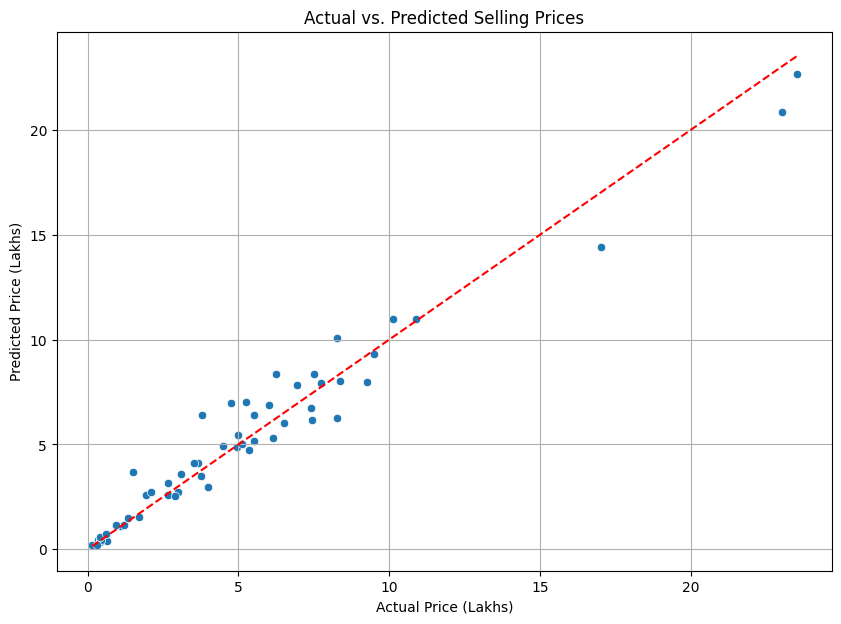

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Actual_Price', y='Predicted_Price', data=results)
plt.plot([results['Actual_Price'].min(), results['Actual_Price'].max()],
         [results['Actual_Price'].min(), results['Actual_Price'].max()],
         color='red', linestyle='--')
plt.title('Actual vs. Predicted Selling Prices')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.grid(True)
plt.show()


This scatter plot visually represents how well the model's predictions align with the actual prices. Ideally, all points would lie on the red dashed line, which signifies a perfect prediction where `Actual_Price = Predicted_Price`. The closer the points are to this line, the more accurate our model is.

### Understanding the Model's Output for Non-Coders

For someone who doesn't code, the most important part is the **predicted selling price** for a car.

Imagine you are looking at a used car. You know its 'Present Price' (what a new car of that model might cost today), how many 'Kms Driven', how many 'Owners' it had, its 'Age', what 'Fuel Type' it uses, whether it's from a 'Dealer' or an 'Individual', and if it has 'Manual' or 'Automatic' transmission.

Our model takes all this information and gives you an **estimated fair selling price**.

**How to use it:**

1.  **Find a car you like:** Note down its details (e.g., Present Price, Kms Driven, Age, Fuel Type, etc.).
2.  **Input these details into a simplified tool** (which could be built using this model in the background).
3.  **Get the predicted price:** The model will tell you, for example, "Based on these features, the predicted selling price for this car is: ₹ 5.57 Lakhs."

**What does this mean for you?**

*   **If the seller is asking for *less* than the predicted price:** It might be a good deal! The car could be undervalued.
*   **If the seller is asking for *more* than the predicted price:** The car might be overpriced, and you could try to negotiate the price down or look for a better deal elsewhere.

The scatter plot you saw earlier (`Actual vs. Predicted Selling Prices`) is a visual check for the model's accuracy. If most dots are close to the red line, it means the model is generally good at predicting prices. For a non-coder, this simply means you can trust the predictions more.

### Key Takeaways for Non-Technical Stakeholders

This project has developed a **Car Price Prediction Model** that helps in estimating the fair market value of used cars. Here’s what you need to know:

*   **What it does:** The model takes key information about a used car (like its age, how many kilometers it's driven, its current showroom price, fuel type, and whether it's sold by a dealer or an individual) and predicts a realistic selling price.

*   **Who benefits and how:**
    *   **Buyers:** Can use the predicted price as a benchmark to avoid overpaying and identify good deals.
    *   **Sellers:** Can use it to price their cars competitively, ensuring they don't undersell or overprice.
    *   **Businesses/Analysts:** Gain insights into factors that influence car prices, helping with inventory management, marketing, and strategic planning.

*   **How accurate is it?** We've tested the model, and it shows a high level of accuracy (an R-squared score of 0.96 means it explains 96% of the variation in car prices). This indicates that its predictions are very close to actual market prices. The visual chart (Actual vs. Predicted Selling Prices) confirms this, as most predicted prices are very near the actual prices.

In essence, this model provides a reliable, data-driven tool to make informed decisions in the used car market, benefiting both individuals and businesses.